In [15]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Reshape
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import random

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [16]:
def load_and_preprocess_data():
    """
    Loads the Fashion MNIST dataset and preprocesses it for the Keras model.
    """
    (X_train, y_train_original), (X_test, y_test_original) = fashion_mnist.load_data()
    
    class_names = [
        "T-Shirt/top", "Trouser", "Pullover", "Dress", "Coat",
        "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"
    ]
    
    # 1. Normalize the images (scale pixel values from 0-255 to 0-1)
    X_train = X_train / 255.0
    X_test = X_test / 255.0
    
    # 2. Reshape data (Flatten)
    num_pixels = X_train.shape[1] * X_train.shape[2]  # 28 * 28 = 784
    X_train_processed = X_train.reshape(X_train.shape[0], num_pixels).astype('float32')
    X_test_processed = X_test.reshape(X_test.shape[0], num_pixels).astype('float32')
    
    # 3. One-hot encode labels
    y_train_cat = to_categorical(y_train_original, 10)
    y_test_cat = to_categorical(y_test_original, 10)
    
    num_classes = 10
    
    return (X_train_processed, y_train_cat, X_test_processed, y_test_cat,
            y_test_original, class_names, X_test)

# Load data
(X_train_processed, y_train_cat, X_test_processed, y_test_cat,
 y_test_original, class_names, X_test_images) = load_and_preprocess_data()

input_dim = X_train_processed.shape[1]
num_classes = y_train_cat.shape[1]

print(f"Training data shape: {X_train_processed.shape}")
print(f"Test data shape: {X_test_processed.shape}")
print(f"Number of classes: {num_classes}")

Training data shape: (60000, 784)
Test data shape: (10000, 784)
Number of classes: 10


In [ ]:
def build_improved_dense_model(input_dim, num_classes):
    """
    Builds an improved Sequential Keras model with better regularization.
    """
    model = Sequential([
        Dense(units=256, input_shape=(input_dim,), activation="relu"),
        Dropout(0.5),  # Increased dropout
        
        Dense(units=128, activation="relu"),
        Dropout(0.5),  # Added dropout to second layer
        
        Dense(units=64, activation="relu"),
        Dropout(0.3),  # Added third layer with dropout
        
        Dense(units=num_classes, activation="softmax")
    ])
    
    optimizer = keras.optimizers.Adam(learning_rate=0.0001)
    
    model.compile(
        loss="categorical_crossentropy",
        optimizer=optimizer,
        metrics=["accuracy"]
    )
    
    model.summary()
    return model

model = build_improved_dense_model(input_dim, num_classes)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
def build_cnn_model(num_classes):
    """
    Builds a CNN model - generally performs better on image data.
    Comment out the dense model above and use this for best results.
    """
    model = Sequential([
        # Reshape flattened input back to 28x28
        Reshape((28, 28, 1), input_shape=(784,)),
        
        # First convolutional block
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Second convolutional block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        # Third convolutional block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        Dropout(0.25),
        
        # Flatten and dense layers
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    
    optimizer = keras.optimizers.Adam(learning_rate=0.001)
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    model.summary()
    return model

model = build_cnn_model(num_classes)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 943,082 (3.60 MB)

 Trainable params: 943,082 (3.60 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,  # Stop if no improvement for 10 epochs
    restore_best_weights=True,  # Restore weights from best epoch
    verbose=1
)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Reduce LR by half
    patience=5,  # Wait 5 epochs before reducing
    min_lr=1e-7,
    verbose=1
)

print("Callbacks configured:")
print("- Early Stopping (patience=10)")
print("- Learning Rate Reduction (patience=5)")

Callbacks configured:
- Early Stopping (patience=10)
- Learning Rate Reduction (patience=5)


In [22]:
BATCH_SIZE = 128
EPOCHS = 50 

history = model.fit(
    X_train_processed,
    y_train_cat,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,  # Use 20% of training data for validation
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n" + "="*70)
print("MODEL TRAINING COMPLETE")
print("="*70)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.5919 - loss: 1.5295 - val_accuracy: 0.8519 - val_loss: 0.4908 - learning_rate: 0.0010
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.7938 - loss: 0.7339 - val_accuracy: 0.8741 - val_loss: 0.3675 - learning_rate: 0.0010
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.8341 - loss: 0.5290 - val_accuracy: 0.8828 - val_loss: 0.3420 - learning_rate: 0.0010
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.8519 - loss: 0.4807 - val_accuracy: 0.8784 - val_loss: 0.3801 - learning_rate: 0.0010
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.8464 - loss: 0.5410 - val_accuracy: 0.8849 - val_loss: 0.4322 - learning_rate: 0.0010
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.8470 - loss: 0.5860 - val_accuracy: 0.8836 - val_loss: 0.4203 - learning_rate: 0.0010
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.8408 - l

In [23]:
print("\n--- Evaluating Model on Test Data ---")
test_loss, test_acc = model.evaluate(X_test_processed, y_test_cat, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Make predictions
y_pred_probs = model.predict(X_test_processed, verbose=0)
y_pred_classes = np.argmax(y_pred_probs, axis=1)


--- Evaluating Model on Test Data ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8722 - loss: 0.3651

Test Loss: 0.3609
Test Accuracy: 87.10%


In [24]:
def plot_training_history(history):
    """
    Plots the training & validation accuracy and loss curves.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plotting training and validation loss
    ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax1.set_title('Loss per Epoch', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plotting training and validation accuracy
    ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax2.set_title('Accuracy per Epoch', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [25]:
def plot_confusion_matrix(y_true, y_pred_classes, class_names):
    """
    Plots a confusion matrix using Seaborn.
    """
    cf_matrix = confusion_matrix(y_true, y_pred_classes)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.title('Confusion Matrix for the Test Set', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def visualize_predictions(X_test_images, y_true, y_pred_classes, class_names, num_images=5):
    """
    Visualizes correct and incorrect predictions.
    """
    correct_indices = np.where(y_pred_classes == y_true)[0]
    incorrect_indices = np.where(y_pred_classes != y_true)[0]
    
    # Plot Correct Predictions
    print("\n--- Correct Predictions ---")
    fig1, axes1 = plt.subplots(1, num_images, figsize=(15, 3))
    fig1.suptitle('Correct Predictions', fontsize=16, color='green', fontweight='bold')
    
    for i, ax in enumerate(axes1):
        if i < len(correct_indices):
            idx = correct_indices[random.randint(0, len(correct_indices)-1)]
            ax.imshow(X_test_images[idx], cmap="gray")
            ax.set_title(f"Pred: {class_names[y_pred_classes[idx]]}\nTrue: {class_names[y_true[idx]]}", 
                        fontsize=10, color='green')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Plot Incorrect Predictions
    print("\n--- Incorrect Predictions ---")
    fig2, axes2 = plt.subplots(1, num_images, figsize=(15, 3))
    fig2.suptitle('Incorrect Predictions', fontsize=16, color='red', fontweight='bold')
    
    for i, ax in enumerate(axes2):
        if i < len(incorrect_indices):
            idx = incorrect_indices[random.randint(0, len(incorrect_indices)-1)]
            ax.imshow(X_test_images[idx], cmap="gray")
            ax.set_title(f"Pred: {class_names[y_pred_classes[idx]]}\nTrue: {class_names[y_true[idx]]}", 
                        fontsize=10, color='red')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()



VISUALIZING RESULTS

--- Training History ---


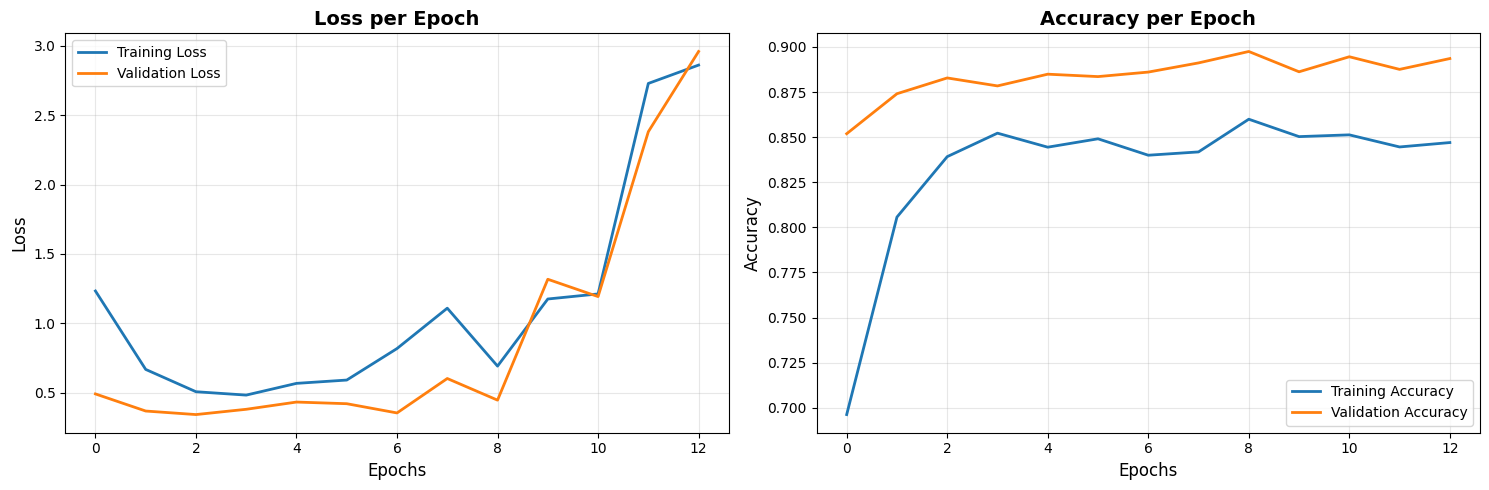


--- Confusion Matrix ---


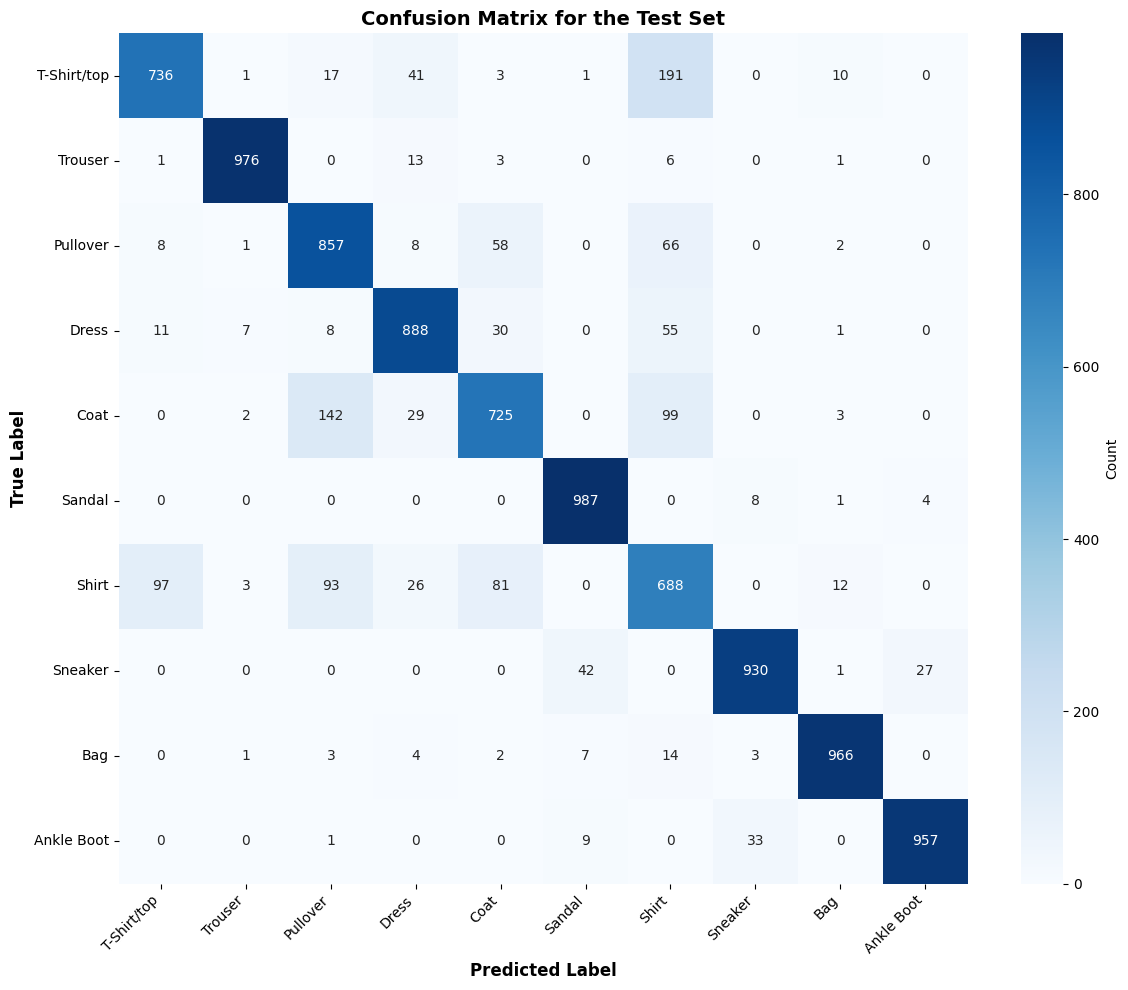


--- Example Predictions ---

--- Correct Predictions ---


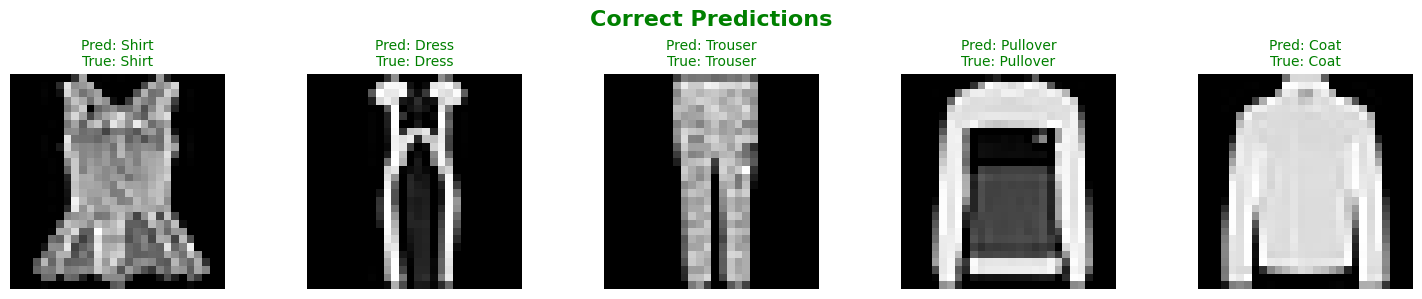


--- Incorrect Predictions ---


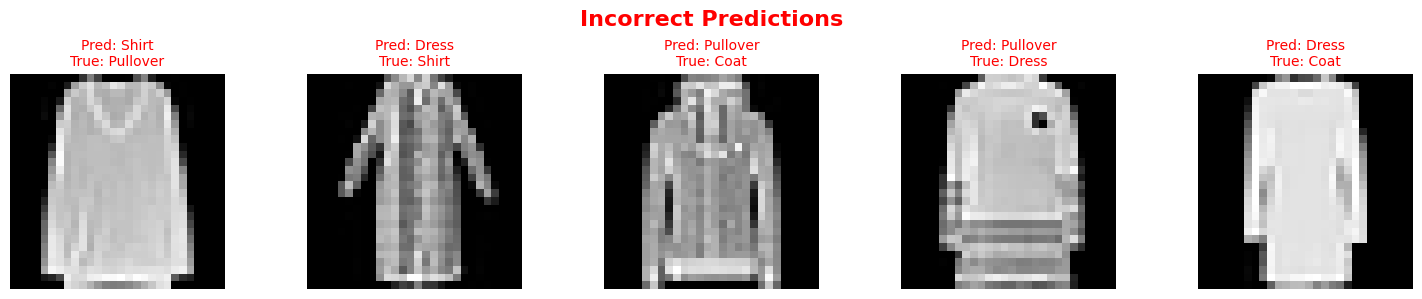

In [26]:
print("\n" + "="*70)
print("VISUALIZING RESULTS")
print("="*70)

print("\n--- Training History ---")
plot_training_history(history)

print("\n--- Confusion Matrix ---")
plot_confusion_matrix(y_test_original, y_pred_classes, class_names)

print("\n--- Example Predictions ---")
visualize_predictions(X_test_images, y_test_original, y_pred_classes, class_names)